# 🔮 Time Series Forecasting with LSTM (TensorFlow / Keras)
> **Full Pipeline:** Dataset Generation → Preprocessing → Model Training → Evaluation → Visualization → Export to TensorFlow.js

---

## 📋 Table of Contents
1. [Install Dependencies](#1)
2. [Import Libraries](#2)
3. [Generate Dataset](#3)
4. [Exploratory Data Analysis (EDA)](#4)
5. [Preprocess Data](#5)
6. [Build LSTM Model](#6)
7. [Train Model](#7)
8. [Evaluate & Predict](#8)
9. [Visualize Results](#9)
10. [Export to TensorFlow.js](#10)
11. [Use Model in Website](#11)

---
## 1. 📦 Install Dependencies <a name="1"></a>

In [21]:
# Install required packages
!pip install tensorflowjs --quiet
!pip install matplotlib seaborn scikit-learn pandas numpy --quiet

print("✅ All packages installed successfully!")

✅ All packages installed successfully!


---
## 2. 📚 Import Libraries <a name="2"></a>

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os
import json

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Bidirectional, BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam

import tensorflowjs as tfjs

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"✅ TensorFlow version : {tf.__version__}")
print(f"✅ TensorFlow.js version: {tfjs.__version__}")
print(f"✅ NumPy version      : {np.__version__}")

✅ TensorFlow version : 2.19.0
✅ TensorFlow.js version: 4.22.0
✅ NumPy version      : 2.0.2


---
## 3. 🗄️ Generate Dataset <a name="3"></a>

We simulate a **realistic stock-price-like time series** that combines:
- 📈 Long-term upward trend
- 🔄 Seasonal / cyclical patterns (weekly + yearly)
- 🎲 Random Gaussian noise
- ⚡ Occasional shock events

This mimics real-world scenarios (energy demand, sales, temperature, stock prices).

In [51]:
# ── Configuration ──────────────────────────────────────────────────────────────
N_STEPS = 8000                 # Total computation steps
INITIAL_NOISE = 100            # Starting noise budget
RESET_THRESHOLD = 20           # When to simulate bootstrapping reset

# ── Generate Synthetic FHE Noise Dataset ──────────────────────────────────────
import pandas as pd
import numpy as np

data = []

noise_budget = INITIAL_NOISE
depth = 0

for step in range(N_STEPS):

    # Random operation type
    operation = np.random.choice(["add", "mul"])

    # Noise increment logic
    if operation == "add":
        delta = np.random.uniform(1, 3)
    else:
        delta = np.random.uniform(5, 10)

    # Random spike (simulate heavy computation)
    if operation == "mul" and np.random.rand() > 0.7:
        delta *= 1.5

    depth += 1
    noise_budget -= delta

    # Simulate bootstrapping (reset)
    bootstrapped = 0
    if noise_budget < RESET_THRESHOLD:
        noise_budget = INITIAL_NOISE
        depth = 0
        bootstrapped = 1

    data.append({
        "step": step,
        "operation": operation,
        "depth": depth,
        "noise_budget": noise_budget,
        "delta_noise": delta,
        "bootstrapped": bootstrapped
    })

# ── Create DataFrame ──────────────────────────────────────────────────────────
df = pd.DataFrame(data)
df["delta_noise"] = np.clip(df["delta_noise"], 0, 12)

# Encode categorical feature
df["op_encoded"] = df["operation"].map({"add": 0, "mul": 1})

# Target variable (next step prediction)
df["next_noise"] = df["noise_budget"].shift(-1)
df["since_reset"] = df["depth"]
df["noise_ratio"] = df["noise_budget"] / 100
df.dropna(inplace=True)

# ── Dataset Summary ───────────────────────────────────────────────────────────
print("📊 DATASET SUMMARY")
print(f"   Total Steps         : {len(df)}")
print(f"   Features            : {list(df.columns)}")
print(f"   Bootstraps Triggered: {df['bootstrapped'].sum()} times")

print("\n📈 NOISE STATISTICS")
print(f"   Noise Range         : {df['noise_budget'].min():.2f} → {df['noise_budget'].max():.2f}")
print(f"   Avg Noise Drop/Step : {df['delta_noise'].mean():.2f}")

print("\n🔁 OPERATION DISTRIBUTION")
print(df["operation"].value_counts())

print("\n📋 FIRST 5 ROWS")
print(df.head())

# ── Feature Description ───────────────────────────────────────────────────────
print("\n🧠 FEATURE DESCRIPTION")
print(" step            → Computation step index")
print(" operation       → Type of operation (add/mul)")
print(" depth           → Number of operations since last reset")
print(" noise_budget    → Remaining noise before failure")
print(" delta_noise     → Noise added in current step")
print(" bootstrapped    → Indicates if reset occurred (1 = yes)")
print(" op_encoded      → Encoded operation (add=0, mul=1)")
print(" next_noise      → Target value for prediction")

📊 DATASET SUMMARY
   Total Steps         : 7999
   Features            : ['step', 'operation', 'depth', 'noise_budget', 'delta_noise', 'bootstrapped', 'op_encoded', 'next_noise', 'since_reset', 'noise_ratio']
   Bootstraps Triggered: 504 times

📈 NOISE STATISTICS
   Noise Range         : 20.00 → 100.00
   Avg Noise Drop/Step : 5.20

🔁 OPERATION DISTRIBUTION
operation
add    4007
mul    3992
Name: count, dtype: int64

📋 FIRST 5 ROWS
   step operation  depth  noise_budget  delta_noise  bootstrapped  op_encoded  \
0     0       mul      1     92.401305     7.598695             0           1   
1     1       mul      2     84.942525     7.458780             0           1   
2     2       mul      3     77.759691     7.182834             0           1   
3     3       add      4     76.502902     1.256789             0           0   
4     4       add      5     75.330506     1.172396             0           0   

   next_noise  since_reset  noise_ratio  
0   84.942525            1     0.92

In [52]:
# ── Save dataset to CSV ───────────────────────────────────────────────────────
df.to_csv('sahf_noise_dataset.csv', index=False)

print("✅ Dataset saved to sahf_noise_dataset.csv")

# ── Dataset Statistics ────────────────────────────────────────────────────────
print("\n📝 DATASET STATISTICS")

print("\n📊 Core Features Summary:")
print(df[['noise_budget', 'delta_noise', 'depth']].describe().round(2))

print("\n🔁 Bootstrapping Stats:")
print(f"   Total Bootstraps : {df['bootstrapped'].sum()}")
print(f"   Bootstrap Rate   : {(df['bootstrapped'].mean()*100):.2f}%")

print("\n🔧 Operation Distribution:")
print(df['operation'].value_counts())

print("\n🎯 Target Variable Summary (Next Noise):")
print(df['next_noise'].describe().round(2))

✅ Dataset saved to sahf_noise_dataset.csv

📝 DATASET STATISTICS

📊 Core Features Summary:
       noise_budget  delta_noise    depth
count       7999.00      7999.00  7999.00
mean          61.84         5.20     7.67
std           24.06         3.54     4.97
min           20.00         1.00     0.00
25%           41.05         2.01     3.00
50%           61.76         2.99     7.00
75%           82.76         8.27    11.00
max          100.00        12.00    23.00

🔁 Bootstrapping Stats:
   Total Bootstraps : 504
   Bootstrap Rate   : 6.30%

🔧 Operation Distribution:
operation
add    4007
mul    3992
Name: count, dtype: int64

🎯 Target Variable Summary (Next Noise):
count    7999.00
mean       61.84
std        24.06
min        20.00
25%        41.05
50%        61.73
75%        82.75
max       100.00
Name: next_noise, dtype: float64


---
## 4. 🔍 Exploratory Data Analysis (EDA) <a name="4"></a>

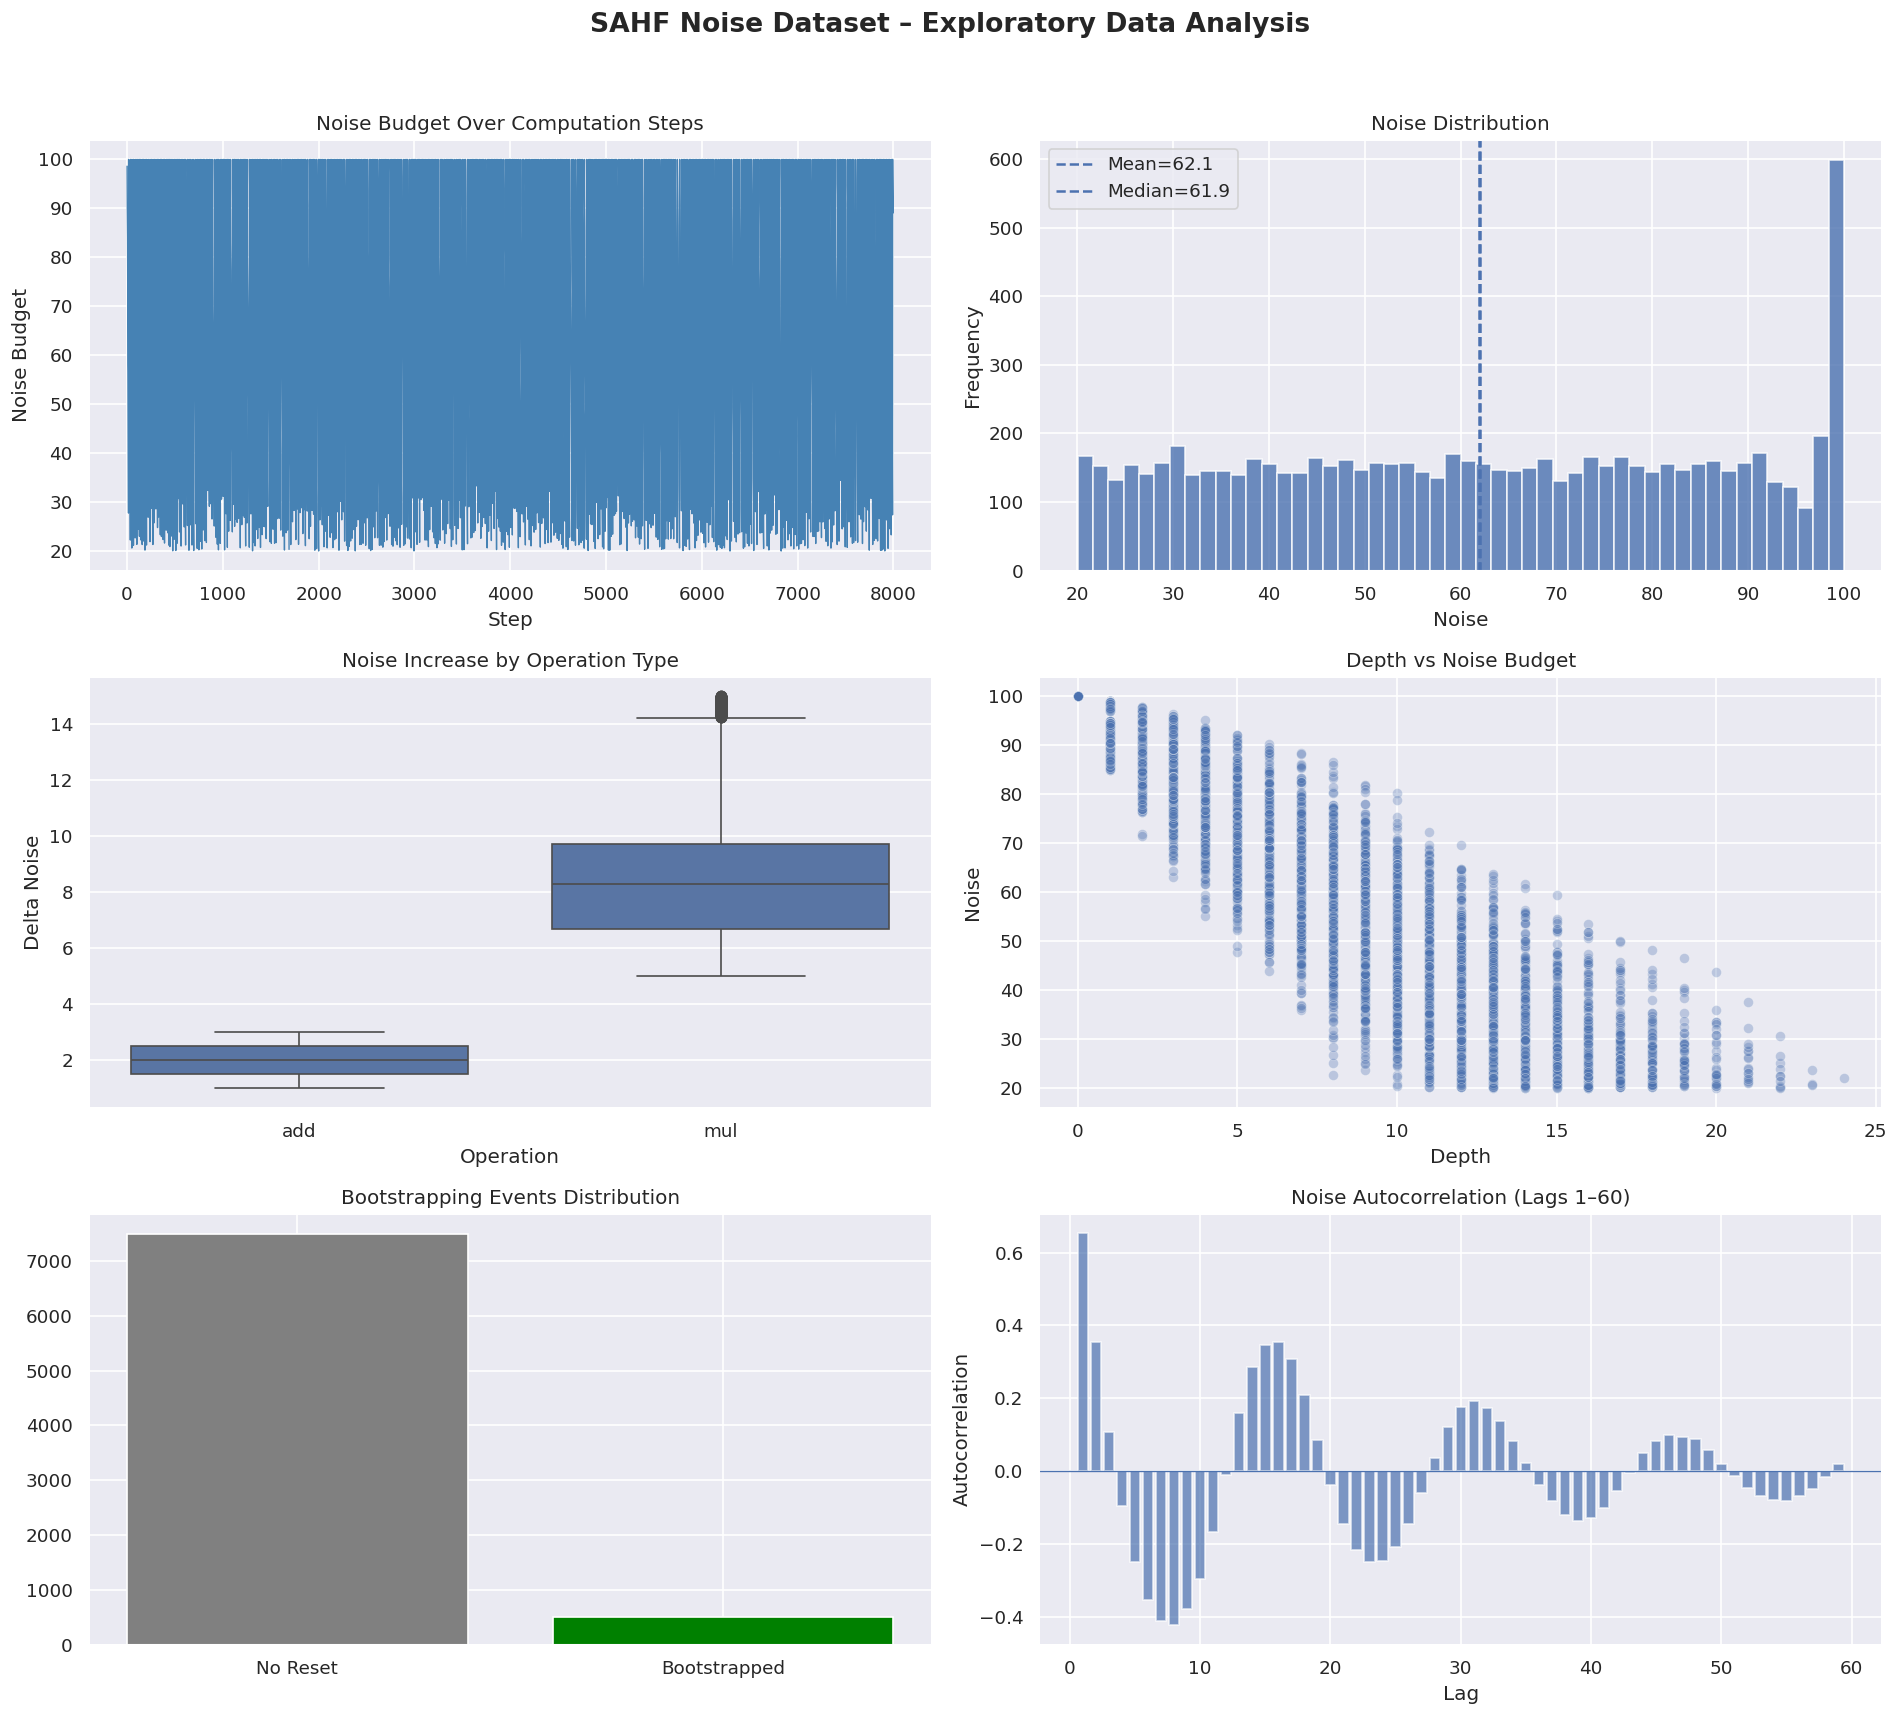

✅ SAHF EDA plots saved to sahf_eda_plots.png


In [43]:
# ── SAHF Dataset – Exploratory Data Analysis ───────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('SAHF Noise Dataset – Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.02)

# 1. Noise over time
ax = axes[0, 0]
ax.plot(df['step'], df['noise_budget'], color='steelblue', linewidth=0.8)
ax.set_title('Noise Budget Over Computation Steps')
ax.set_xlabel('Step'); ax.set_ylabel('Noise Budget')

# 2. Noise distribution
ax = axes[0, 1]
ax.hist(df['noise_budget'], bins=50, alpha=0.8)
ax.axvline(df['noise_budget'].mean(), linestyle='--', label=f"Mean={df['noise_budget'].mean():.1f}")
ax.axvline(df['noise_budget'].median(), linestyle='--', label=f"Median={df['noise_budget'].median():.1f}")
ax.set_title('Noise Distribution')
ax.set_xlabel('Noise'); ax.set_ylabel('Frequency')
ax.legend()

# 3. Operation impact on noise
ax = axes[1, 0]
sns.boxplot(x='operation', y='delta_noise', data=df, ax=ax)
ax.set_title('Noise Increase by Operation Type')
ax.set_xlabel('Operation'); ax.set_ylabel('Delta Noise')

# 4. Depth vs Noise
ax = axes[1, 1]
sns.scatterplot(x='depth', y='noise_budget', data=df, alpha=0.3, ax=ax)
ax.set_title('Depth vs Noise Budget')
ax.set_xlabel('Depth'); ax.set_ylabel('Noise')

# 5. Bootstrapping events
ax = axes[2, 0]
bootstrap_counts = df['bootstrapped'].value_counts()
ax.bar(['No Reset', 'Bootstrapped'], bootstrap_counts, color=['gray','green'])
ax.set_title('Bootstrapping Events Distribution')

# 6. Autocorrelation (noise)
ax = axes[2, 1]
lags = range(1, 60)
autocorr = [df['noise_budget'].autocorr(lag=l) for l in lags]
ax.bar(lags, autocorr, alpha=0.7)
ax.axhline(0, linewidth=0.8)
ax.set_title('Noise Autocorrelation (Lags 1–60)')
ax.set_xlabel('Lag'); ax.set_ylabel('Autocorrelation')

plt.tight_layout()
plt.savefig('sahf_eda_plots.png', bbox_inches='tight')
plt.show()

print("✅ SAHF EDA plots saved to sahf_eda_plots.png")

---
## 5. ⚙️ Preprocess Data <a name="5"></a>

Steps:
1. **Scale** features to [0, 1] using MinMaxScaler
2. **Create sliding windows** — input sequence of `WINDOW_SIZE` timesteps → predict next value
3. **Split** into train / validation / test sets (chronologically)

In [50]:
# ── Feature selection (SAHF Dataset) ──────────────────────────────────────────
FEATURES = ['noise_budget', 'depth', 'delta_noise', 'op_encoded']
TARGET   = 'next_noise'

data = df[FEATURES].values
target = df[[TARGET]].values
WINDOW_SIZE = 100
print("📊 Selected Features:", FEATURES)
print("🎯 Target Variable :", TARGET)

# ── Scale ─────────────────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()
data_scaled = feature_scaler.fit_transform(data)

target_scaler = MinMaxScaler()
target_scaled = target_scaler.fit_transform(target)

# ── Create sliding windows ────────────────────────────────────────────────────
def create_sequences(data, target, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i - window:i])
        y.append(target[i])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, target_scaled, WINDOW_SIZE)

# ── Chronological train/val/test split ────────────────────────────────────────
total   = len(X)
n_test  = int(total * TEST_SPLIT)
n_val   = int(total * VAL_SPLIT)
n_train = total - n_test - n_val

X_train, y_train = X[:n_train],             y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],        y[n_train+n_val:]

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n📐 DATA SHAPES")
print(f"   Input Shape        : {X.shape}  (samples, timesteps, features)")
print(f"   Train Shape        : {X_train.shape}")
print(f"   Validation Shape   : {X_val.shape}")
print(f"   Test Shape         : {X_test.shape}")

print("\n📏 CONFIGURATION")
print(f"   Window Size        : {WINDOW_SIZE}")
print(f"   Number of Features : {len(FEATURES)}")

print("\n📊 SAMPLE INPUT (First Sequence)")
print(X[0])

print("\n🎯 SAMPLE TARGET")
print(y[0])

📊 Selected Features: ['noise_budget', 'depth', 'delta_noise', 'op_encoded']
🎯 Target Variable : next_noise

📐 DATA SHAPES
   Input Shape        : (7919, 80, 4)  (samples, timesteps, features)
   Train Shape        : (5545, 80, 4)
   Validation Shape   : (1187, 80, 4)
   Test Shape         : (1187, 80, 4)

📏 CONFIGURATION
   Window Size        : 80
   Number of Features : 4

📊 SAMPLE INPUT (First Sequence)
[[0.97886612 0.04347826 0.04933491 0.        ]
 [0.94692141 0.08695652 0.11112666 0.        ]
 [0.91833451 0.13043478 0.09193435 0.        ]
 [0.84091122 0.17391304 0.37107013 1.        ]
 [0.70626523 0.2173913  0.69813978 1.        ]
 [0.62216718 0.26086957 0.40922121 1.        ]
 [0.58881919 0.30434783 0.11914749 0.        ]
 [0.55853363 0.34782609 0.10164344 0.        ]
 [0.53148732 0.39130435 0.08312876 0.        ]
 [0.4237368  0.43478261 0.54441243 1.        ]
 [0.40966695 0.47826087 0.00895878 0.        ]
 [0.38191293 0.52173913 0.08717387 0.        ]
 [0.35928776 0.56521739 0.0

---
## 6. 🧠 Build LSTM Model <a name="6"></a>

Architecture: **Stacked Bidirectional LSTM** with:
- Bidirectional LSTM layers (captures both past and future context in training)
- Batch Normalization (stabilizes training)
- Dropout (prevents overfitting)
- Dense output layer

In [46]:
# ── Callbacks ────────────────────────────────────────────────────────────────
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

# ── Train Model ──────────────────────────────────────────────────────────────
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ── Training Summary ─────────────────────────────────────────────────────────
print("\n✅ TRAINING COMPLETE")
print(f"   Best val_loss : {min(history.history['val_loss']):.6f}")
print(f"   Best val_mae  : {min(history.history['val_mae']):.6f}")
print(f"   Epochs run    : {len(history.history['loss'])}")

Epoch 1/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 22s 78ms/step - loss: 0.1555 - mae: 0.4299 - val_loss: 0.0725 - val_mae: 0.3139 - learning_rate: 0.0010
Epoch 2/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - loss: 0.0578 - mae: 0.2633 - val_loss: 0.0399 - val_mae: 0.2328 - learning_rate: 0.0010
Epoch 3/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 22s 85ms/step - loss: 0.0415 - mae: 0.2185 - val_loss: 0.0244 - val_mae: 0.1611 - learning_rate: 0.0010
Epoch 4/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 16s 91ms/step - loss: 0.0338 - mae: 0.1925 - val_loss: 0.0213 - val_mae: 0.1383 - learning_rate: 0.0010
Epoch 5/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - loss: 0.0300 - mae: 0.1769 - val_loss: 0.0206 - val_mae: 0.1308 - learning_rate: 0.0010
Epoch 6/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - loss: 0.0277 - mae: 0.1668 - val_loss: 0.0202 - val_mae: 0.1338 - learning_rate: 0.0010
Epoch 7/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - loss: 0.0267 - mae: 0.1631 - val_loss: 0.0218 - val_mae: 0.1333 - learning_rate:

---
## 7. 🏋️ Train Model <a name="7"></a>

In [47]:
# ── Load Best Model (Optional) ────────────────────────────────────────────────
from tensorflow.keras.models import load_model

model = load_model('best_model.keras')

# ── Predictions ───────────────────────────────────────────────────────────────
y_pred_scaled = model.predict(X_test)

# Inverse transform
y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_true = target_scaler.inverse_transform(y_test)

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# Normalized MAE (important for your project)
nmae = mae / (y_true.max() - y_true.min())

print("\n📊 MODEL PERFORMANCE (TEST SET)")
print(f"   MAE        : {mae:.4f}")
print(f"   RMSE       : {rmse:.4f}")
print(f"   NMAE       : {nmae*100:.2f}%")

# ── Sample Predictions ─────────────────────────────────────────────────────────
print("\n🔍 SAMPLE PREDICTIONS")
for i in range(5):
    print(f"   Actual: {y_true[i][0]:.2f}  |  Predicted: {y_pred[i][0]:.2f}")

# ── Prediction vs Actual Plot ─────────────────────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_true[:200], label='Actual', linewidth=2)
plt.plot(y_pred[:200], label='Predicted', linestyle='--')
plt.title('Prediction vs Actual (First 200 Samples)')
plt.xlabel('Time Step')
plt.ylabel('Noise Budget')
plt.legend()
plt.grid(alpha=0.3)

plt.savefig('prediction_plot.png', bbox_inches='tight')
plt.show()

print("\n✅ Prediction plot saved to prediction_plot.png")

ValueError: Exception encountered when calling LSTMCell.call().

[1mDimensions must be equal, but are 4 and 7 for '{{node sequential_1_1/bidirectional_1_1/forward_lstm_3_1/lstm_cell_1/MatMul}} = MatMul[T=DT_FLOAT, grad_a=false, grad_b=false, transpose_a=false, transpose_b=false](sequential_1_1/bidirectional_1_1/forward_lstm_3_1/strided_slice_1, sequential_1_1/bidirectional_1_1/forward_lstm_3_1/lstm_cell_1/Cast/ReadVariableOp)' with input shapes: [32,4], [7,256].[0m

Arguments received by LSTMCell.call():
  • inputs=tf.Tensor(shape=(32, 4), dtype=float32)
  • states=('tf.Tensor(shape=(32, 64), dtype=float32)', 'tf.Tensor(shape=(32, 64), dtype=float32)')
  • training=False

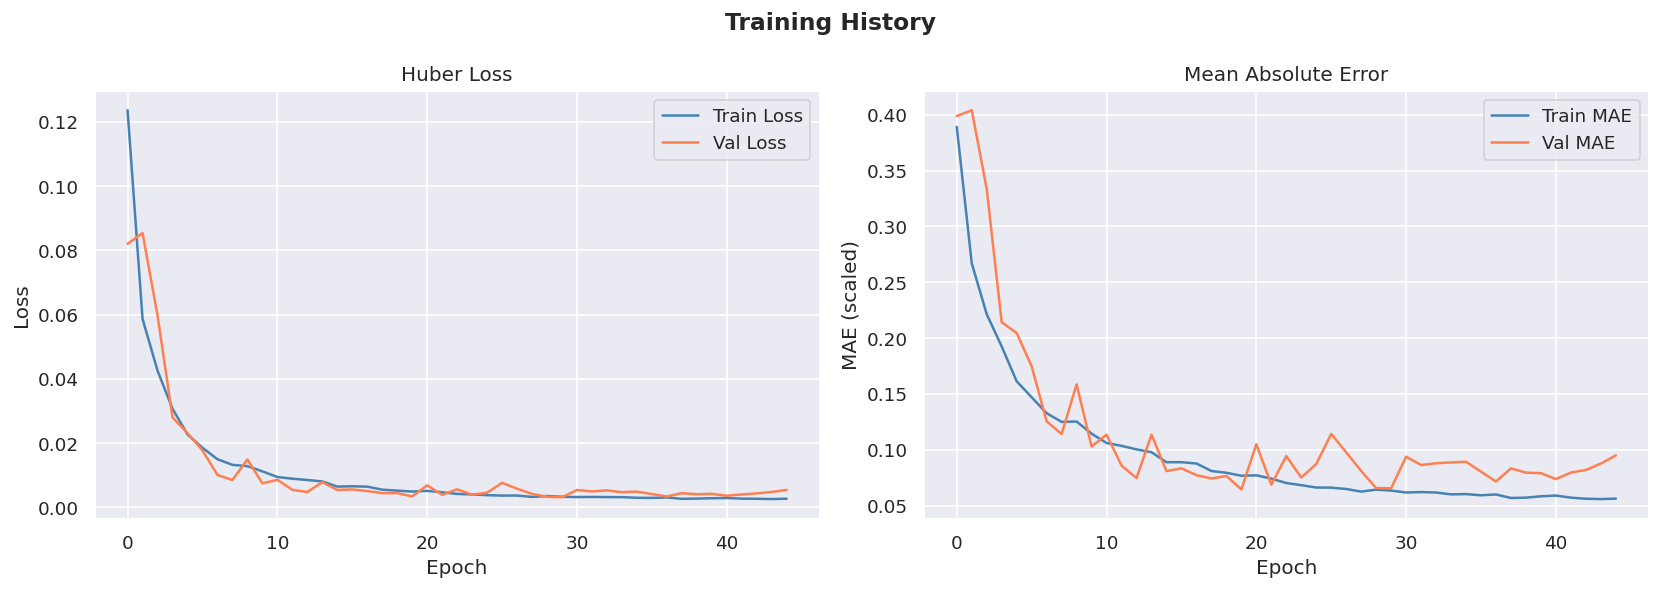

✅ Training history plot saved.


In [29]:
# ── Plot training curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

# Loss
ax = axes[0]
ax.plot(history.history['loss'],     label='Train Loss', color='steelblue')
ax.plot(history.history['val_loss'], label='Val Loss',   color='coral')
ax.set_title('Huber Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend()

# MAE
ax = axes[1]
ax.plot(history.history['mae'],     label='Train MAE', color='steelblue')
ax.plot(history.history['val_mae'], label='Val MAE',   color='coral')
ax.set_title('Mean Absolute Error')
ax.set_xlabel('Epoch'); ax.set_ylabel('MAE (scaled)')
ax.legend()

plt.tight_layout()
plt.savefig('training_history.png', bbox_inches='tight')
plt.show()
print("✅ Training history plot saved.")

---
## 8. 📊 Evaluate & Predict <a name="8"></a>

In [30]:
# ── Predictions ───────────────────────────────────────────────────────────────
y_pred_train_scaled = model.predict(X_train, verbose=0)
y_pred_val_scaled   = model.predict(X_val,   verbose=0)
y_pred_test_scaled  = model.predict(X_test,  verbose=0)

# Inverse transform to original scale
y_pred_train = target_scaler.inverse_transform(y_pred_train_scaled)
y_pred_val   = target_scaler.inverse_transform(y_pred_val_scaled)
y_pred_test  = target_scaler.inverse_transform(y_pred_test_scaled)

y_true_train = target_scaler.inverse_transform(y_train.reshape(-1, 1))
y_true_val   = target_scaler.inverse_transform(y_val.reshape(-1, 1))
y_true_test  = target_scaler.inverse_transform(y_test.reshape(-1, 1))

# ── Metrics ───────────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"📌 {label:10s} | MAE: {mae:6.3f}  RMSE: {rmse:6.3f}  R²: {r2:.4f}  MAPE: {mape:.2f}%")
    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'mape': mape}

print("═" * 65)
print(f"{'METRIC SUMMARY':^65}")
print("═" * 65)
train_metrics = compute_metrics(y_true_train, y_pred_train, 'Train')
val_metrics   = compute_metrics(y_true_val,   y_pred_val,   'Validation')
test_metrics  = compute_metrics(y_true_test,  y_pred_test,  'Test')
print("═" * 65)

# Save metrics to JSON
metrics_dict = {'train': train_metrics, 'val': val_metrics, 'test': test_metrics}
with open('metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=2)
print("\n✅ Metrics saved to metrics.json")

═════════════════════════════════════════════════════════════════
                         METRIC SUMMARY                          
═════════════════════════════════════════════════════════════════
📌 Train      | MAE:  4.296  RMSE:  5.616  R²: 0.9532  MAPE: 3.06%
📌 Validation | MAE:  9.674  RMSE: 11.753  R²: 0.4117  MAPE: 4.89%
📌 Test       | MAE: 17.263  RMSE: 19.594  R²: -1.0289  MAPE: 8.18%
═════════════════════════════════════════════════════════════════

✅ Metrics saved to metrics.json


In [31]:
# ── Multi-step future forecast ─────────────────────────────────────────────────
FUTURE_STEPS = 30  # Forecast 30 days into the future

# Use the last window from the test set as seed
last_window = data_scaled[-WINDOW_SIZE:].copy()   # shape: (60, n_features)
future_preds = []

for _ in range(FUTURE_STEPS):
    inp = last_window.reshape(1, WINDOW_SIZE, n_features)
    pred = model.predict(inp, verbose=0)[0, 0]
    future_preds.append(pred)

    # Roll window: drop oldest, append new prediction in target column
    new_row = last_window[-1].copy()
    new_row[target_col_idx] = pred
    last_window = np.vstack([last_window[1:], new_row])

# Inverse transform
future_preds_arr = np.array(future_preds).reshape(-1, 1)
future_values    = target_scaler.inverse_transform(future_preds_arr).flatten()

last_date         = df.index[-1]
future_dates      = pd.date_range(start=last_date + pd.Timedelta(days=1),
                                   periods=FUTURE_STEPS, freq='D')

print(f"✅ {FUTURE_STEPS}-day future forecast generated")
print(f"   Forecast range: {future_dates[0].date()} → {future_dates[-1].date()}")
print(f"   Predicted range: {future_values.min():.2f} → {future_values.max():.2f}")

✅ 30-day future forecast generated
   Forecast range: 2026-04-09 → 2026-05-08
   Predicted range: 193.93 → 196.23


---
## 9. 📈 Visualize Results <a name="9"></a>

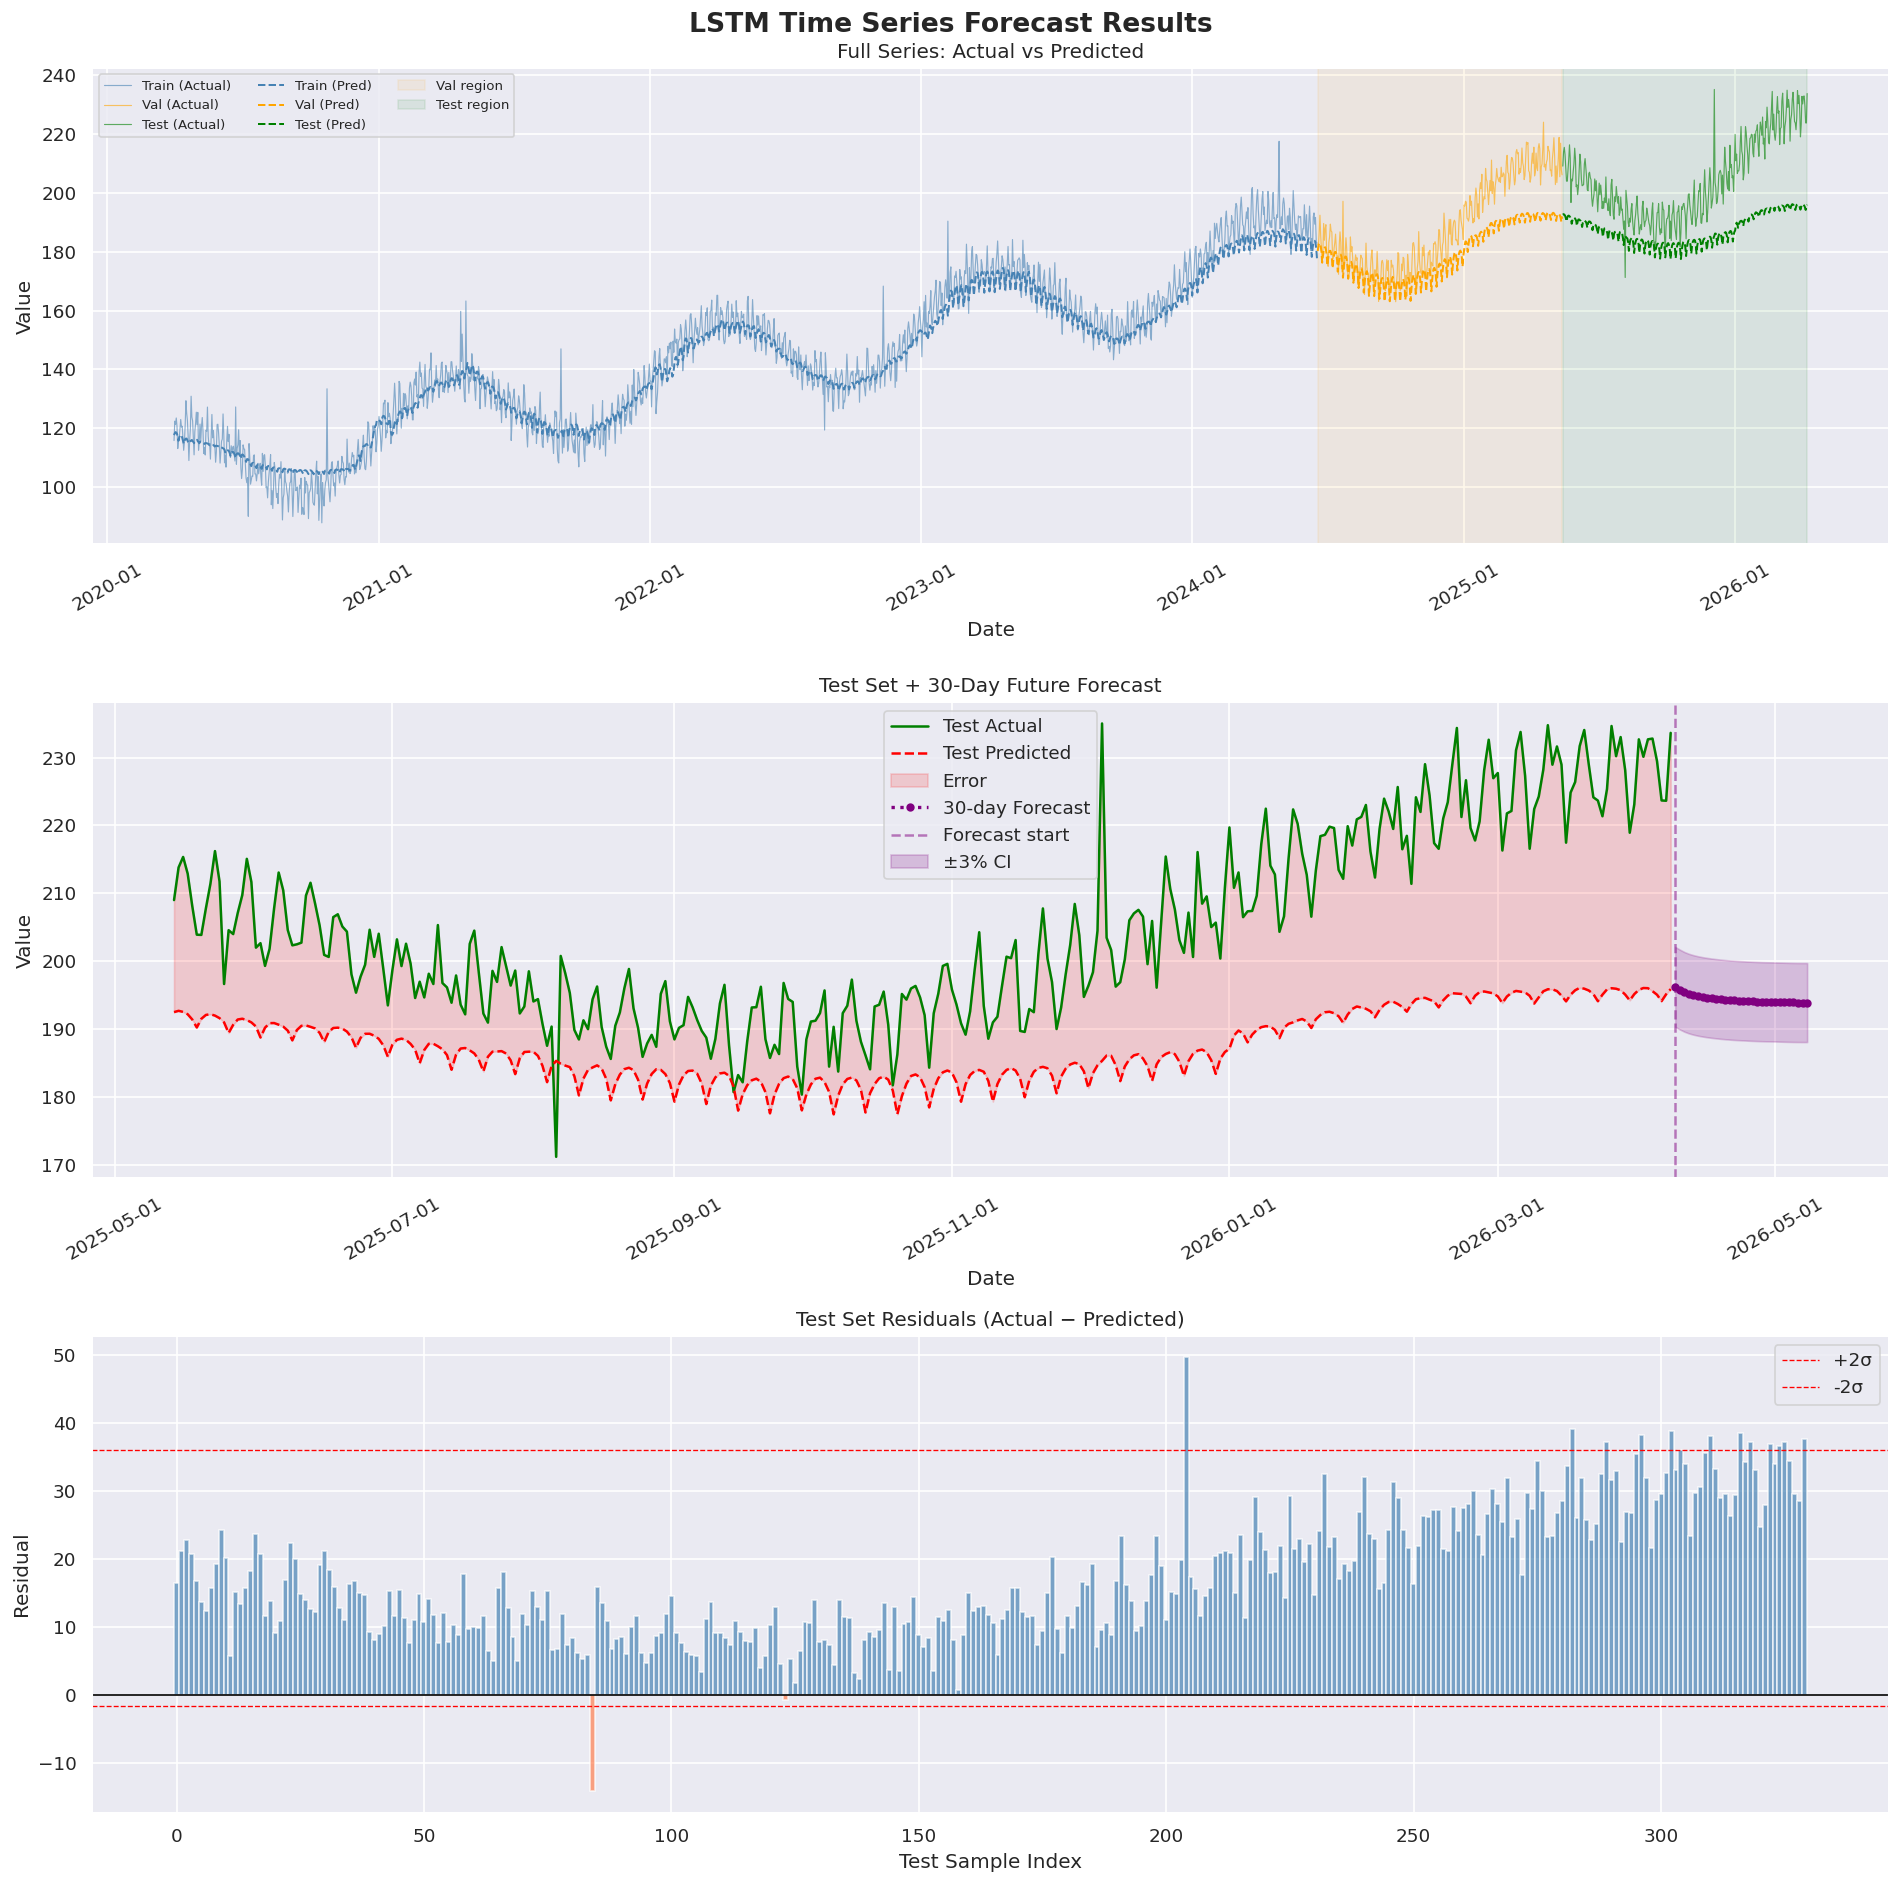

✅ Forecast results plot saved to forecast_results.png


In [32]:
# ── Reconstruct dates for each split ──────────────────────────────────────────
dates_all   = df.index[WINDOW_SIZE:]
dates_train = dates_all[:n_train]
dates_val   = dates_all[n_train:n_train + n_val]
dates_test  = dates_all[n_train + n_val:]

fig, axes = plt.subplots(3, 1, figsize=(16, 16))
fig.suptitle('LSTM Time Series Forecast Results', fontsize=16, fontweight='bold')

# ── 1. Full overview ──────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(dates_train, y_true_train, color='steelblue',  lw=0.7, alpha=0.6, label='Train (Actual)')
ax.plot(dates_val,   y_true_val,   color='orange',      lw=0.7, alpha=0.6, label='Val (Actual)')
ax.plot(dates_test,  y_true_test,  color='green',       lw=0.7, alpha=0.6, label='Test (Actual)')
ax.plot(dates_train, y_pred_train, color='steelblue',  lw=1.2, linestyle='--', label='Train (Pred)')
ax.plot(dates_val,   y_pred_val,   color='orange',      lw=1.2, linestyle='--', label='Val (Pred)')
ax.plot(dates_test,  y_pred_test,  color='green',       lw=1.2, linestyle='--', label='Test (Pred)')
# Shade regions
ax.axvspan(dates_val[0], dates_val[-1],   alpha=0.08, color='orange', label='Val region')
ax.axvspan(dates_test[0], dates_test[-1], alpha=0.08, color='green',  label='Test region')
ax.set_title('Full Series: Actual vs Predicted')
ax.set_xlabel('Date'); ax.set_ylabel('Value')
ax.legend(ncol=3, fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# ── 2. Test set close-up + future forecast ────────────────────────────────────
ax = axes[1]
ax.plot(dates_test, y_true_test, color='green',  lw=1.5, label='Test Actual')
ax.plot(dates_test, y_pred_test, color='red',    lw=1.5, linestyle='--', label='Test Predicted')
ax.fill_between(dates_test,
                y_true_test.flatten(), y_pred_test.flatten(),
                alpha=0.15, color='red', label='Error')
# Future forecast
ax.plot(future_dates, future_values, color='purple', lw=2, linestyle=':', marker='o',
        markersize=4, label=f'{FUTURE_STEPS}-day Forecast')
ax.axvline(x=future_dates[0], color='purple', linestyle='--', alpha=0.5, label='Forecast start')
ax.fill_between(future_dates,
                future_values * 0.97, future_values * 1.03,
                alpha=0.2, color='purple', label='±3% CI')
ax.set_title(f'Test Set + {FUTURE_STEPS}-Day Future Forecast')
ax.set_xlabel('Date'); ax.set_ylabel('Value')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# ── 3. Residuals plot ─────────────────────────────────────────────────────────
ax = axes[2]
residuals = y_true_test.flatten() - y_pred_test.flatten()
ax.bar(range(len(residuals)), residuals,
       color=np.where(residuals >= 0, 'steelblue', 'coral'), alpha=0.7, width=1)
ax.axhline(0, color='black', lw=1)
ax.axhline(residuals.mean() + 2*residuals.std(), color='red',
           linestyle='--', lw=0.8, label='+2σ')
ax.axhline(residuals.mean() - 2*residuals.std(), color='red',
           linestyle='--', lw=0.8, label='-2σ')
ax.set_title('Test Set Residuals (Actual − Predicted)')
ax.set_xlabel('Test Sample Index'); ax.set_ylabel('Residual')
ax.legend()

plt.tight_layout()
plt.savefig('forecast_results.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Forecast results plot saved to forecast_results.png")

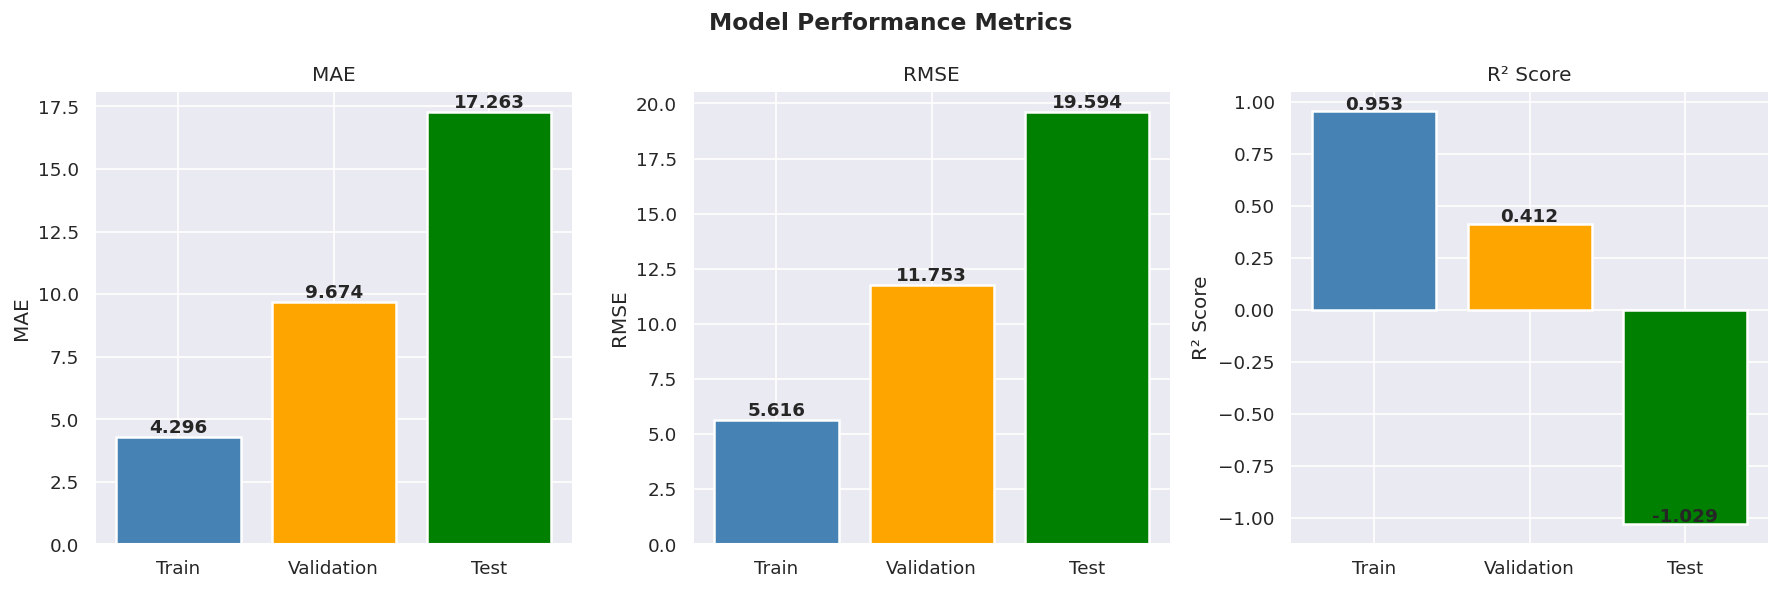

✅ Metrics dashboard saved to metrics_dashboard.png


In [33]:
# ── Metrics dashboard ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Performance Metrics', fontsize=14, fontweight='bold')

sets    = ['Train', 'Validation', 'Test']
colors  = ['steelblue', 'orange', 'green']
metrics = [train_metrics, val_metrics, test_metrics]

for idx, (metric_name, ylabel) in enumerate([('mae','MAE'), ('rmse','RMSE'), ('r2','R² Score')]):
    ax = axes[idx]
    vals = [m[metric_name] for m in metrics]
    bars = ax.bar(sets, vals, color=colors, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)
    ax.set_title(ylabel)
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.savefig('metrics_dashboard.png', bbox_inches='tight')
plt.show()
print("✅ Metrics dashboard saved to metrics_dashboard.png")

---
## 10. 🌐 Export to TensorFlow.js <a name="10"></a>

We'll export the trained Keras model to **TensorFlow.js format** so it can run directly in the browser — no server required!

The export produces:
- `model.json` — architecture + metadata
- `group1-shard1of1.bin` — model weights

In [34]:
# ── Export Keras model to TensorFlow.js ───────────────────────────────────────
TFJS_OUTPUT_DIR = './tfjs_model'
os.makedirs(TFJS_OUTPUT_DIR, exist_ok=True)

tfjs.converters.save_keras_model(model, TFJS_OUTPUT_DIR)

print(f"✅ Model exported to TensorFlow.js format!")
print(f"📁 Output directory: {TFJS_OUTPUT_DIR}")
print("\n📋 Exported files:")
for f in sorted(os.listdir(TFJS_OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(TFJS_OUTPUT_DIR, f))
    print(f"   {f:<40} {size/1024:.1f} KB")

failed to lookup keras version from the file,
    this is likely a weight only file
✅ Model exported to TensorFlow.js format!
📁 Output directory: ./tfjs_model

📋 Exported files:
   group1-shard1of1.bin                     241.8 KB
   model.json                               13.4 KB
   scaler_params.json                       0.9 KB


In [35]:
# ── Save scaler parameters for use in the browser ─────────────────────────────
scaler_params = {
    'features': FEATURES,
    'target': TARGET,
    'window_size': WINDOW_SIZE,
    'feature_min': scaler.data_min_.tolist(),
    'feature_max': scaler.data_max_.tolist(),
    'feature_scale': scaler.scale_.tolist(),
    'target_min': float(target_scaler.data_min_[0]),
    'target_max': float(target_scaler.data_max_[0]),
    'target_scale': float(target_scaler.scale_[0]),
    'metrics': {
        'test_mae':  round(test_metrics['mae'], 4),
        'test_rmse': round(test_metrics['rmse'], 4),
        'test_r2':   round(test_metrics['r2'], 4),
        'test_mape': round(test_metrics['mape'], 2)
    }
}

with open(os.path.join(TFJS_OUTPUT_DIR, 'scaler_params.json'), 'w') as f:
    json.dump(scaler_params, f, indent=2)

print("✅ Scaler parameters saved to tfjs_model/scaler_params.json")
print(f"\n📋 Scaler params preview:")
print(json.dumps({k: v for k, v in scaler_params.items() if k not in ['feature_min','feature_max','feature_scale']}, indent=2))

✅ Scaler parameters saved to tfjs_model/scaler_params.json

📋 Scaler params preview:
{
  "features": [
    "Value",
    "Rolling_Mean_7",
    "Rolling_Mean_30",
    "Lag_1",
    "Lag_7",
    "Day_of_Week",
    "Month"
  ],
  "target": "Value",
  "window_size": 60,
  "target_min": 87.95727084544586,
  "target_max": 235.01650520609044,
  "target_scale": 0.006799981003216865,
  "metrics": {
    "test_mae": 17.2634,
    "test_rmse": 19.5936,
    "test_r2": -1.0289,
    "test_mape": 8.18
  }
}


In [36]:
# ── Zip and download the model ─────────────────────────────────────────────────
import shutil

shutil.make_archive('tfjs_model_export', 'zip', TFJS_OUTPUT_DIR)

print("✅ Model zipped: tfjs_model_export.zip")
print(f"📦 Zip size: {os.path.getsize('tfjs_model_export.zip') / 1024:.1f} KB")

# Download in Colab
try:
    from google.colab import files
    files.download('tfjs_model_export.zip')
    print("⬇️  Download started!")
except ImportError:
    print("ℹ️  Not in Colab — file saved locally as tfjs_model_export.zip")

✅ Model zipped: tfjs_model_export.zip
📦 Zip size: 226.3 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Download started!


---
## 11. 🌍 Use Model in Your Website <a name="11"></a>

After downloading `tfjs_model_export.zip`, extract it and host the files. Below is a **complete ready-to-use HTML page** that:
- Loads TensorFlow.js from CDN
- Loads your exported model
- Accepts 60 days of input values
- Predicts the next day's value in-browser

> 💡 **No server needed** — runs entirely in the browser!

In [37]:
html_code = '''
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <title>Time Series Forecast – TF.js</title>
  <!-- TensorFlow.js -->
  <script src="https://cdn.jsdelivr.net/npm/@tensorflow/tfjs@4.15.0/dist/tf.min.js"></script>
  <!-- Chart.js for visualization -->
  <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
  <style>
    * { box-sizing: border-box; margin: 0; padding: 0; }
    body { font-family: 'Segoe UI', sans-serif; background: #0f172a; color: #e2e8f0; min-height: 100vh; padding: 2rem; }
    h1   { font-size: 1.8rem; color: #38bdf8; margin-bottom: 0.5rem; }
    p.sub { color: #94a3b8; margin-bottom: 2rem; }
    .card { background: #1e293b; border-radius: 12px; padding: 1.5rem; margin-bottom: 1.5rem; }
    label { display: block; margin-bottom: 0.5rem; font-weight: 600; color: #cbd5e1; }
    textarea { width: 100%; height: 120px; background: #0f172a; color: #e2e8f0;
               border: 1px solid #334155; border-radius: 8px; padding: 0.75rem; font-size: 0.85rem; }
    button { background: #0ea5e9; color: white; border: none; border-radius: 8px;
             padding: 0.75rem 1.5rem; font-size: 1rem; cursor: pointer; margin-top: 1rem; }
    button:hover { background: #38bdf8; }
    button:disabled { background: #475569; cursor: not-allowed; }
    .result { font-size: 2rem; font-weight: 700; color: #4ade80; margin-top: 1rem; }
    .status { color: #94a3b8; font-size: 0.9rem; margin-top: 0.5rem; }
    canvas  { max-width: 100%; }
  </style>
</head>
<body>
  <h1>🔮 Time Series Forecaster</h1>
  <p class="sub">Powered by LSTM + TensorFlow.js — runs 100% in your browser</p>

  <div class="card">
    <label>📁 Load TF.js Model (select the model.json file)</label>
    <input type="file" id="modelFile" multiple accept=".json,.bin" />
    <p class="status" id="modelStatus">⏳ No model loaded yet</p>
  </div>

  <div class="card">
    <label>📊 Input: Last 60 Daily Values (comma-separated)</label>
    <textarea id="inputValues" placeholder="e.g. 102.3, 103.1, 101.8, ..."></textarea>
    <button id="predictBtn" onclick="predict()" disabled>Predict Next Day ➜</button>
  </div>

  <div class="card" id="resultCard" style="display:none">
    <label>📈 Prediction Result</label>
    <div class="result" id="resultValue"></div>
    <p class="status" id="resultDetail"></p>
    <canvas id="forecastChart" style="margin-top:1.5rem"></canvas>
  </div>

  <script>
    let model = null;
    let scalerParams = null;
    const WINDOW_SIZE = 60;

    // ── Load scaler params alongside model ─────────────────────────────────────
    document.getElementById('modelFile').addEventListener('change', async (e) => {
      const files = Array.from(e.target.files);
      const jsonFile = files.find(f => f.name === 'model.json');
      if (!jsonFile) { alert('Please select model.json'); return; }

      document.getElementById('modelStatus').textContent = '⏳ Loading model...';
      try {
        model = await tf.loadLayersModel(tf.io.browserFiles([jsonFile, ...files.filter(f => f.name.endsWith('.bin'))]));
        document.getElementById('modelStatus').textContent = '✅ Model loaded! Ready to predict.';
        document.getElementById('predictBtn').disabled = false;

        // Try to load scaler_params.json
        const scalerFile = files.find(f => f.name === 'scaler_params.json');
        if (scalerFile) {
          scalerParams = JSON.parse(await scalerFile.text());
          document.getElementById('modelStatus').textContent += ' Scaler loaded.';
        }
      } catch (err) {
        document.getElementById('modelStatus').textContent = '❌ Error: ' + err.message;
      }
    });

    // ── Normalise a single value using MinMaxScaler params ────────────────────
    function scaleValue(val, min, max) {
      return (val - min) / (max - min);
    }
    function inverseScaleValue(val, min, max) {
      return val * (max - min) + min;
    }

    // ── Run prediction ────────────────────────────────────────────────────────
    async function predict() {
      const raw = document.getElementById('inputValues').value
        .split(',').map(v => parseFloat(v.trim())).filter(v => !isNaN(v));

      if (raw.length < WINDOW_SIZE) {
        alert(`Please provide at least ${WINDOW_SIZE} values. You provided ${raw.length}.`); return;
      }

      const window = raw.slice(-WINDOW_SIZE);
      const tMin = scalerParams ? scalerParams.target_min : Math.min(...window);
      const tMax = scalerParams ? scalerParams.target_max : Math.max(...window);

      // Build input tensor [1, 60, n_features] — use Value as first feature
      const nFeatures = scalerParams ? scalerParams.features.length : 1;
      const inputData = [];
      for (let i = 0; i < WINDOW_SIZE; i++) {
        const row = [];
        const fMin = scalerParams ? scalerParams.feature_min : [tMin];
        const fMax = scalerParams ? scalerParams.feature_max : [tMax];
        for (let f = 0; f < nFeatures; f++) {
          const v = (f === 0) ? window[i] : window[Math.max(0, i - f)];
          row.push(scaleValue(v, fMin[f], fMax[f]));
        }
        inputData.push(row);
      }

      const tensor = tf.tensor3d([inputData]);
      const predTensor = model.predict(tensor);
      const predScaled = (await predTensor.data())[0];
      const predValue  = inverseScaleValue(predScaled, tMin, tMax);

      tensor.dispose(); predTensor.dispose();

      const lastVal = window[window.length - 1];
      const change  = predValue - lastVal;
      const changePct = (change / lastVal * 100).toFixed(2);
      const arrow   = change >= 0 ? '▲' : '▼';

      document.getElementById('resultCard').style.display = 'block';
      document.getElementById('resultValue').textContent = `${predValue.toFixed(2)}`;
      document.getElementById('resultDetail').textContent =
        `${arrow} ${Math.abs(change).toFixed(2)} (${changePct}%) vs last value of ${lastVal.toFixed(2)}`;

      drawChart(window, predValue);
    }

    // ── Draw chart ────────────────────────────────────────────────────────────
    let chartInstance = null;
    function drawChart(history, prediction) {
      if (chartInstance) chartInstance.destroy();
      const labels = [...history.map((_, i) => `T-${WINDOW_SIZE - 1 - i}`), 'T+1'];
      const data   = [...history, null];
      const predData = [...Array(history.length).fill(null), prediction];

      chartInstance = new Chart(document.getElementById('forecastChart'), {
        type: 'line',
        data: {
          labels,
          datasets: [
            { label: 'Historical', data, borderColor: '#38bdf8', backgroundColor: 'transparent',
              pointRadius: 2, tension: 0.3 },
            { label: 'Forecast', data: predData, borderColor: '#4ade80', backgroundColor: 'rgba(74,222,128,0.3)',
              pointRadius: 8, pointStyle: 'star', tension: 0 }
          ]
        },
        options: {
          responsive: true,
          plugins: { legend: { labels: { color: '#e2e8f0' } } },
          scales: {
            x: { ticks: { color: '#94a3b8', maxTicksLimit: 12 }, grid: { color: '#1e293b' } },
            y: { ticks: { color: '#94a3b8' }, grid: { color: '#334155' } }
          }
        }
      });
    }
  </script>
</body>
</html>
'''

with open('forecast_website.html', 'w') as f:
    f.write(html_code)

print("✅ Website HTML saved to forecast_website.html")

# Download it
try:
    from google.colab import files
    files.download('forecast_website.html')
    print("⬇️  HTML download started!")
except ImportError:
    print("ℹ️  File saved locally as forecast_website.html")

✅ Website HTML saved to forecast_website.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  HTML download started!


---
## ✅ Summary

| Step | Description | Output File |
|------|-------------|-------------|
| 1 | Install dependencies | — |
| 2 | Import libraries | — |
| 3 | Generate synthetic dataset | `time_series_dataset.csv` |
| 4 | Exploratory Data Analysis | `eda_plots.png` |
| 5 | Preprocess + create sequences | — |
| 6 | Build Bidirectional LSTM model | — |
| 7 | Train with callbacks | `best_model.keras`, `training_history.png` |
| 8 | Evaluate + 30-day forecast | `metrics.json` |
| 9 | Visualize results | `forecast_results.png`, `metrics_dashboard.png` |
| 10 | Export to TensorFlow.js | `tfjs_model_export.zip` |
| 11 | Ready-to-use website | `forecast_website.html` |

### 🚀 How to deploy on your website
1. Extract `tfjs_model_export.zip` → you get `model.json` + `.bin` + `scaler_params.json`
2. Place all files in the **same folder** as `forecast_website.html`
3. Open `forecast_website.html` in any modern browser — **no server needed!**
4. Click `Load Model`, select `model.json` (and `.bin` files), then enter 60 values and click **Predict**

> 💡 To deploy publicly, host the files on **GitHub Pages**, **Netlify**, or **Vercel** for free!